# Numpy Text Models (Baseline + DNN)

Notebook version of `train_text_models.py` with no CLI/argparse.

Workflow:
1. Edit the **Parameters** cell
2. Run cells top → bottom

In [44]:
from __future__ import annotations

from pathlib import Path
import numpy as np
import pandas as pd


def find_project_dir(start: Path | None = None) -> Path:
    """Find the `projeto/` directory from the current working directory.

    We look for a folder that contains `splits/train.csv`.
    """
    if start is None:
        start = Path.cwd()

    for p in [start] + list(start.parents):
        # Case 1: we are somewhere above `projeto/`
        cand = p / "projeto"
        if (cand / "splits" / "train.csv").exists():
            return cand

        # Case 2: we are already inside `projeto/` (or below it)
        if (p / "splits" / "train.csv").exists():
            return p

    raise FileNotFoundError(
        "Could not locate projeto/ (expected splits/train.csv). "
        "Open the workspace root or set PROJECT_DIR manually."
    )


PROJECT_DIR = find_project_dir()

print("PROJECT_DIR:", PROJECT_DIR)

PROJECT_DIR: c:\Users\User\Desktop\2º Semestre\Aprendizagem Profunda\projeto


In [45]:
# ===============================
# Self-contained "numpy framework"
# (merged from projeto/numpy/*.py)
# ===============================

import re
import copy
from abc import ABCMeta, abstractmethod


# ---------- data.py ----------
class Data:
    def __init__(self, X, y=None, features=None, label=None):
        if X is None:
            raise ValueError("X cannot be None")
        if y is not None and len(X) != len(y):
            raise ValueError("X and y must have the same length")
        if features is not None and len(X[0]) != len(features):
            raise ValueError("Number of features must match the number of columns in X")
        if features is None:
            features = [f"feat_{str(i)}" for i in range(X.shape[1])]
        if y is not None and label is None:
            label = "y"
        self.X = X
        self.y = y
        self.features = features
        self.label = label

    def shape(self):
        return self.X.shape

    def has_label(self):
        return self.y is not None

    def get_classes(self):
        if self.has_label():
            return np.unique(self.y)
        raise ValueError("Dataset does not have a label")

    def get_mean(self):
        return np.nanmean(self.X, axis=0)

    def get_variance(self):
        return np.nanvar(self.X, axis=0)

    def get_median(self):
        return np.nanmedian(self.X, axis=0)

    def get_min(self):
        return np.nanmin(self.X, axis=0)

    def get_max(self):
        return np.nanmax(self.X, axis=0)

    def summary(self):
        data = {
            "mean": self.get_mean(),
            "median": self.get_median(),
            "min": self.get_min(),
            "max": self.get_max(),
            "var": self.get_variance(),
        }
        return pd.DataFrame.from_dict(data, orient="index", columns=self.features)


# ---------- optimizer.py ----------
class Optimizer:
    def __init__(self, learning_rate=0.01, momentum=0.90):
        self.retained_gradient = None
        self.learning_rate = learning_rate
        self.momentum = momentum

    def update(self, w, grad_loss_w):
        if self.retained_gradient is None:
            self.retained_gradient = np.zeros(np.shape(w))
        self.retained_gradient = self.momentum * self.retained_gradient + (1 - self.momentum) * grad_loss_w
        return w - self.learning_rate * self.retained_gradient


# ---------- layers.py ----------
class Layer(metaclass=ABCMeta):
    @abstractmethod
    def forward_propagation(self, inputs, training):
        raise NotImplementedError

    @abstractmethod
    def backward_propagation(self, error):
        raise NotImplementedError

    @abstractmethod
    def output_shape(self):
        raise NotImplementedError

    @abstractmethod
    def parameters(self):
        raise NotImplementedError

    def set_input_shape(self, input_shape):
        self._input_shape = input_shape

    def input_shape(self):
        return self._input_shape

    def layer_name(self):
        return self.__class__.__name__


class DenseLayer(Layer):
    def __init__(self, n_units, input_shape=None, l2_lambda: float = 0.0, initialization: str = "xavier"):
        super().__init__()
        self.n_units = n_units
        self._input_shape = input_shape
        self.l2_lambda = float(l2_lambda)
        self.initialization = str(initialization).lower() if initialization is not None else "xavier"
        self.input = None
        self.output = None
        self.weights = None
        self.biases = None

    def initialize(self, optimizer):
        input_dim = self.input_shape()[0]
        if self.initialization == "he":
            std = np.sqrt(2.0 / input_dim)
            self.weights = np.random.randn(input_dim, self.n_units) * std
        elif self.initialization == "xavier":
            limit = np.sqrt(6.0 / (input_dim + self.n_units))
            self.weights = np.random.uniform(-limit, limit, (input_dim, self.n_units))
        else:
            self.weights = np.random.randn(input_dim, self.n_units) * 0.01
        self.biases = np.zeros((1, self.n_units))
        self.w_opt = copy.deepcopy(optimizer)
        self.b_opt = copy.deepcopy(optimizer)
        return self

    def parameters(self):
        return np.prod(self.weights.shape) + np.prod(self.biases.shape)

    def forward_propagation(self, inputs, training):
        self.input = inputs
        self.output = np.dot(self.input, self.weights) + self.biases
        return self.output

    def backward_propagation(self, output_error):
        input_error = np.dot(output_error, self.weights.T)
        weights_error = np.dot(self.input.T, output_error)
        if self.l2_lambda > 0:
            weights_error = weights_error + self.l2_lambda * self.weights
        bias_error = np.sum(output_error, axis=0, keepdims=True)
        self.weights = self.w_opt.update(self.weights, weights_error)
        self.biases = self.b_opt.update(self.biases, bias_error)
        return input_error

    def output_shape(self):
        return (self.n_units,)


class DropoutLayer(Layer):
    def __init__(self, p_drop: float = 0.5, input_shape=None, seed: int = 42):
        super().__init__()
        if not (0.0 <= p_drop < 1.0):
            raise ValueError("p_drop must be in [0, 1)")
        self.p_drop = float(p_drop)
        self._input_shape = input_shape
        self.seed = seed
        self.rng = np.random.default_rng(seed)
        self.mask = None

    def forward_propagation(self, inputs, training):
        if (not training) or self.p_drop == 0.0:
            self.mask = None
            return inputs
        keep_prob = 1.0 - self.p_drop
        self.mask = (self.rng.random(size=inputs.shape) < keep_prob).astype(inputs.dtype)
        return (inputs * self.mask) / keep_prob

    def backward_propagation(self, output_error):
        if self.mask is None or self.p_drop == 0.0:
            return output_error
        keep_prob = 1.0 - self.p_drop
        return (output_error * self.mask) / keep_prob

    def output_shape(self):
        return self._input_shape

    def parameters(self):
        return 0


# ---------- activation.py ----------
class ActivationLayer(Layer):
    def forward_propagation(self, inputs, training):
        self.input = inputs
        self.output = self.activation_function(self.input)
        return self.output

    def backward_propagation(self, output_error):
        return self.derivative(self.input) * output_error

    @abstractmethod
    def activation_function(self, inputs):
        raise NotImplementedError

    @abstractmethod
    def derivative(self, inputs):
        raise NotImplementedError

    def output_shape(self):
        return self._input_shape

    def parameters(self):
        return 0


class SigmoidActivation(ActivationLayer):
    def activation_function(self, inputs):
        return 1 / (1 + np.exp(-inputs))

    def derivative(self, inputs):
        s = self.activation_function(inputs)
        return s * (1 - s)


class ReLUActivation(ActivationLayer):
    def activation_function(self, inputs):
        return np.maximum(0, inputs)

    def derivative(self, inputs):
        return np.where(inputs > 0, 1, 0)


# ---------- losses.py ----------
class LossFunction:
    @abstractmethod
    def loss(self, y_true, y_pred):
        raise NotImplementedError

    @abstractmethod
    def derivative(self, y_true, y_pred):
        raise NotImplementedError


class MeanSquaredError(LossFunction):
    def loss(self, y_true, y_pred):
        return np.mean((y_true - y_pred) ** 2)

    def derivative(self, y_true, y_pred):
        return 2 * (y_pred - y_true) / y_true.shape[0]


class BinaryCrossEntropy(LossFunction):
    def loss(self, y_true, y_pred):
        p = np.clip(y_pred, 1e-15, 1 - 1e-15)
        return -np.mean(y_true * np.log(p) + (1 - y_true) * np.log(1 - p))

    def derivative(self, y_true, y_pred):
        p = np.clip(y_pred, 1e-15, 1 - 1e-15)
        return (p - y_true) / (p * (1 - p) * y_true.shape[0])


class SoftmaxCrossEntropy(LossFunction):
    """Cross-entropy computed from logits (no softmax layer needed)."""
    def _one_hot(self, y_true, n_classes):
        y = np.asarray(y_true).astype(int).ravel()
        oh = np.zeros((len(y), n_classes), dtype=np.float32)
        oh[np.arange(len(y)), y] = 1.0
        return oh

    def _log_softmax(self, logits):
        z = logits - np.max(logits, axis=1, keepdims=True)
        logsumexp = np.log(np.sum(np.exp(z), axis=1, keepdims=True))
        return z - logsumexp

    def loss(self, y_true, y_pred):
        logits = np.asarray(y_pred)
        n = logits.shape[0]
        log_probs = self._log_softmax(logits)
        if np.ndim(y_true) == 1:
            y_oh = self._one_hot(y_true, logits.shape[1])
        else:
            y_oh = np.asarray(y_true)
        return float(-np.sum(y_oh * log_probs) / n)

    def derivative(self, y_true, y_pred):
        logits = np.asarray(y_pred)
        n = logits.shape[0]
        log_probs = self._log_softmax(logits)
        probs = np.exp(log_probs)
        if np.ndim(y_true) == 1:
            y_oh = self._one_hot(y_true, logits.shape[1])
        else:
            y_oh = np.asarray(y_true)
        return (probs - y_oh) / n


# ---------- metrics.py ----------
def accuracy(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    if y_true.ndim == 2 and y_true.shape[1] > 1:
        y_true_idx = np.argmax(y_true, axis=1)
    else:
        y_true_idx = y_true.reshape(-1)
        if y_true_idx.ndim != 1:
            y_true_idx = y_true_idx.ravel()
    if y_pred.ndim == 2 and y_pred.shape[1] > 1:
        y_pred_idx = np.argmax(y_pred, axis=1)
    else:
        y_pred_idx = np.round(y_pred.reshape(-1)).astype(int)
    return float(np.mean(y_pred_idx == y_true_idx))


def softmax_accuracy(y_true, logits):
    return accuracy(y_true, logits)


def mse(y_true, y_pred):
    return np.sum((y_true - y_pred) ** 2) / len(y_true)


# ---------- text_vectorizer.py ----------
_TOKEN_RE = re.compile(r"\b\w+\b", flags=re.UNICODE)


def simple_tokenize(text: str, lowercase: bool = True):
    if text is None:
        return []
    text = str(text)
    if lowercase:
        text = text.lower()
    return _TOKEN_RE.findall(text)


class CountVectorizerNumpy:
    """Minimal CountVectorizer implemented with numpy (dense)."""
    def __init__(self, max_features: int = 5000, min_df: int = 1, lowercase: bool = True, dtype=np.float32):
        self.max_features = int(max_features) if max_features is not None else None
        self.min_df = int(min_df)
        self.lowercase = lowercase
        self.dtype = dtype
        self.vocab_ = None
        self.idf_ = None

    def fit(self, texts):
        doc_freq = {}
        for text in texts:
            tokens = set(simple_tokenize(text, lowercase=self.lowercase))
            for tok in tokens:
                doc_freq[tok] = doc_freq.get(tok, 0) + 1
        items = [(tok, df) for tok, df in doc_freq.items() if df >= self.min_df]
        items.sort(key=lambda x: (-x[1], x[0]))
        if self.max_features is not None:
            items = items[: self.max_features]
        self.vocab_ = {tok: i for i, (tok, _) in enumerate(items)}
        return self

    def transform(self, texts):
        if self.vocab_ is None:
            raise ValueError("Vectorizer not fitted. Call fit() first.")
        n_samples = len(texts)
        n_features = len(self.vocab_)
        X = np.zeros((n_samples, n_features), dtype=self.dtype)
        for i, text in enumerate(texts):
            for tok in simple_tokenize(text, lowercase=self.lowercase):
                j = self.vocab_.get(tok)
                if j is not None:
                    X[i, j] += 1.0
        return X

    def fit_transform(self, texts):
        return self.fit(texts).transform(texts)


class TfidfVectorizerNumpy(CountVectorizerNumpy):
    def __init__(self, max_features: int = 5000, min_df: int = 1, lowercase: bool = True, dtype=np.float32, norm="l2", smooth_idf: bool = True):
        super().__init__(max_features=max_features, min_df=min_df, lowercase=lowercase, dtype=dtype)
        self.norm = norm
        self.smooth_idf = smooth_idf

    def fit(self, texts):
        super().fit(texts)
        n_docs = len(texts)
        df = np.zeros(len(self.vocab_), dtype=np.int32)
        for text in texts:
            seen = set()
            for tok in simple_tokenize(text, lowercase=self.lowercase):
                j = self.vocab_.get(tok)
                if j is None or j in seen:
                    continue
                df[j] += 1
                seen.add(j)
        if self.smooth_idf:
            self.idf_ = np.log((1.0 + n_docs) / (1.0 + df)) + 1.0
        else:
            df = np.maximum(df, 1)
            self.idf_ = np.log(n_docs / df) + 1.0
        self.idf_ = self.idf_.astype(self.dtype)
        return self

    def transform(self, texts):
        X = super().transform(texts)
        if self.idf_ is None:
            raise ValueError("Vectorizer not fitted. Call fit() first.")
        doc_len = np.sum(X, axis=1, keepdims=True)
        doc_len = np.maximum(doc_len, 1.0)
        tf = X / doc_len
        X_tfidf = tf * self.idf_[None, :]
        if self.norm == "l2":
            norms = np.linalg.norm(X_tfidf, axis=1, keepdims=True)
            norms = np.maximum(norms, 1e-12)
            X_tfidf = X_tfidf / norms
        elif self.norm is None:
            pass
        else:
            raise ValueError("norm must be 'l2' or None")
        return X_tfidf.astype(self.dtype)


class CharTfidfVectorizerNumpy:
    def __init__(self, min_n: int = 3, max_n: int = 5, max_features: int = 8000, min_df: int = 2, lowercase: bool = True, dtype=np.float32, norm: str | None = "l2", smooth_idf: bool = True):
        if min_n < 1 or max_n < 1 or max_n < min_n:
            raise ValueError("Invalid n-gram range")
        self.min_n = int(min_n)
        self.max_n = int(max_n)
        self.max_features = int(max_features) if max_features is not None else None
        self.min_df = int(min_df)
        self.lowercase = bool(lowercase)
        self.dtype = dtype
        self.norm = norm
        self.smooth_idf = bool(smooth_idf)
        self.vocab_ = None
        self.idf_ = None

    def _normalize_text(self, text: str) -> str:
        if text is None:
            return ""
        s = str(text)
        if self.lowercase:
            s = s.lower()
        s = re.sub(r"\s+", " ", s).strip()
        return s

    def _iter_ngrams(self, text: str):
        s = self._normalize_text(text)
        L = len(s)
        if L == 0:
            return
        for n in range(self.min_n, self.max_n + 1):
            if L < n:
                continue
            for i in range(0, L - n + 1):
                yield s[i : i + n]

    def fit(self, texts):
        doc_freq = {}
        for text in texts:
            seen = set(self._iter_ngrams(text))
            for ng in seen:
                doc_freq[ng] = doc_freq.get(ng, 0) + 1
        items = [(ng, df) for ng, df in doc_freq.items() if df >= self.min_df]
        items.sort(key=lambda x: (-x[1], x[0]))
        if self.max_features is not None:
            items = items[: self.max_features]
        self.vocab_ = {ng: i for i, (ng, _) in enumerate(items)}
        n_docs = len(texts)
        df = np.zeros(len(self.vocab_), dtype=np.int32)
        for text in texts:
            seen = set()
            for ng in self._iter_ngrams(text):
                j = self.vocab_.get(ng)
                if j is None or j in seen:
                    continue
                df[j] += 1
                seen.add(j)
        if self.smooth_idf:
            self.idf_ = np.log((1.0 + n_docs) / (1.0 + df)) + 1.0
        else:
            df = np.maximum(df, 1)
            self.idf_ = np.log(n_docs / df) + 1.0
        self.idf_ = self.idf_.astype(self.dtype)
        return self

    def transform(self, texts):
        if self.vocab_ is None or self.idf_ is None:
            raise ValueError("Vectorizer not fitted. Call fit() first.")
        n_samples = len(texts)
        n_features = len(self.vocab_)
        X = np.zeros((n_samples, n_features), dtype=self.dtype)
        for i, text in enumerate(texts):
            for ng in self._iter_ngrams(text):
                j = self.vocab_.get(ng)
                if j is not None:
                    X[i, j] += 1.0
        doc_len = np.sum(X, axis=1, keepdims=True)
        doc_len = np.maximum(doc_len, 1.0)
        tf = X / doc_len
        X_tfidf = tf * self.idf_[None, :]
        if self.norm == "l2":
            norms = np.linalg.norm(X_tfidf, axis=1, keepdims=True)
            norms = np.maximum(norms, 1e-12)
            X_tfidf = X_tfidf / norms
        elif self.norm is None:
            pass
        else:
            raise ValueError("norm must be 'l2' or None")
        return X_tfidf.astype(self.dtype)

    def fit_transform(self, texts):
        return self.fit(texts).transform(texts)


# ---------- logistic_regression.py ----------
def _softmax(logits):
    z = logits - np.max(logits, axis=1, keepdims=True)
    exp = np.exp(z)
    return exp / np.sum(exp, axis=1, keepdims=True)


def _one_hot(y, n_classes):
    y = np.asarray(y).astype(int).ravel()
    oh = np.zeros((len(y), n_classes), dtype=np.float32)
    oh[np.arange(len(y)), y] = 1.0
    return oh


class SoftmaxRegression:
    """Multiclass logistic regression (softmax regression) trained with minibatch GD."""
    def __init__(self, learning_rate: float = 0.1, momentum: float = 0.9, epochs: int = 200, batch_size: int = 256, l2: float = 0.0, verbose: bool = False, seed: int = 42):
        self.learning_rate = learning_rate
        self.momentum = momentum
        self.epochs = int(epochs)
        self.batch_size = int(batch_size)
        self.l2 = float(l2)
        self.verbose = verbose
        self.seed = seed
        self.W = None
        self.b = None
        self.w_opt = Optimizer(learning_rate=learning_rate, momentum=momentum)
        self.b_opt = Optimizer(learning_rate=learning_rate, momentum=momentum)
        self.history = {}

    def _iter_batches(self, X, y):
        n = X.shape[0]
        idx = np.arange(n)
        rng = np.random.default_rng(self.seed)
        rng.shuffle(idx)
        for start in range(0, n, self.batch_size):
            sel = idx[start : start + self.batch_size]
            yield X[sel], y[sel]

    def fit(self, X, y, n_classes=None, X_val=None, y_val=None, patience: int = 0, min_delta: float = 0.0):
        X = np.asarray(X)
        y = np.asarray(y).ravel().astype(int)
        n_samples, n_features = X.shape
        if n_classes is None:
            n_classes = int(np.max(y)) + 1
        rng = np.random.default_rng(self.seed)
        self.W = (rng.standard_normal((n_features, n_classes)).astype(np.float32)) * 0.01
        self.b = np.zeros((1, n_classes), dtype=np.float32)
        best = None
        best_val = np.inf
        bad_epochs = 0
        for epoch in range(1, self.epochs + 1):
            losses = []
            for Xb, yb in self._iter_batches(X, y):
                y_oh = _one_hot(yb, n_classes)
                logits = Xb @ self.W + self.b
                probs = _softmax(logits)
                p = np.clip(probs, 1e-15, 1 - 1e-15)
                loss = -np.mean(np.sum(y_oh * np.log(p), axis=1))
                if self.l2 > 0:
                    loss += 0.5 * self.l2 * np.sum(self.W * self.W)
                losses.append(loss)
                grad_logits = (probs - y_oh) / Xb.shape[0]
                grad_W = Xb.T @ grad_logits
                grad_b = np.sum(grad_logits, axis=0, keepdims=True)
                if self.l2 > 0:
                    grad_W += self.l2 * self.W
                self.W = self.w_opt.update(self.W, grad_W)
                self.b = self.b_opt.update(self.b, grad_b)
            train_loss = float(np.mean(losses)) if losses else float("nan")
            self.history[epoch] = {"loss": train_loss}
            val_loss = None
            if X_val is not None and y_val is not None:
                val_loss = self._loss(X_val, y_val, n_classes)
                self.history[epoch]["val_loss"] = val_loss
                if val_loss < (best_val - min_delta):
                    best_val = val_loss
                    best = (self.W.copy(), self.b.copy())
                    bad_epochs = 0
                else:
                    bad_epochs += 1
                if patience and bad_epochs >= patience:
                    if self.verbose:
                        print(f"Early stopping at epoch {epoch}")
                    break
            if self.verbose and (epoch == 1 or epoch % 10 == 0):
                if val_loss is None:
                    print(f"Epoch {epoch}/{self.epochs} - loss: {train_loss:.4f}")
                else:
                    print(f"Epoch {epoch}/{self.epochs} - loss: {train_loss:.4f} - val_loss: {val_loss:.4f}")
        if best is not None:
            self.W, self.b = best
        return self

    def _loss(self, X, y, n_classes):
        y = np.asarray(y).ravel().astype(int)
        y_oh = _one_hot(y, n_classes)
        probs = self.predict_proba(X)
        p = np.clip(probs, 1e-15, 1 - 1e-15)
        loss = -np.mean(np.sum(y_oh * np.log(p), axis=1))
        if self.l2 > 0:
            loss += 0.5 * self.l2 * np.sum(self.W * self.W)
        return float(loss)

    def predict_proba(self, X):
        X = np.asarray(X)
        logits = X @ self.W + self.b
        return _softmax(logits)

    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)


# ---------- neuralnet.py ----------
class NeuralNetwork:
    def __init__(self, epochs=100, batch_size=128, optimizer=None, learning_rate=0.01, momentum=0.90, verbose=False, loss=MeanSquaredError, metric: callable = mse):
        self.epochs = epochs
        self.batch_size = batch_size
        self.optimizer = Optimizer(learning_rate=learning_rate, momentum=momentum)
        self.verbose = verbose
        self.loss = loss()
        self.metric = metric
        self.layers = []
        self.history = {}

    def add(self, layer):
        if self.layers:
            layer.set_input_shape(input_shape=self.layers[-1].output_shape())
        if hasattr(layer, "initialize"):
            layer.initialize(self.optimizer)
        self.layers.append(layer)
        return self

    def get_mini_batches(self, X, y=None, shuffle=True):
        n_samples = X.shape[0]
        indices = np.arange(n_samples)
        assert self.batch_size <= n_samples, "Batch size cannot be greater than the number of samples"
        if shuffle:
            np.random.shuffle(indices)
        for start in range(0, n_samples, self.batch_size):
            if y is not None:
                yield X[indices[start : start + self.batch_size]], y[indices[start : start + self.batch_size]]
            else:
                yield X[indices[start : start + self.batch_size]], None

    def _snapshot_params(self):
        snap = []
        for layer in self.layers:
            if hasattr(layer, "weights") and hasattr(layer, "biases"):
                snap.append({"weights": layer.weights.copy(), "biases": layer.biases.copy()})
            else:
                snap.append(None)
        return snap

    def _restore_params(self, snap):
        for layer, s in zip(self.layers, snap):
            if s is None:
                continue
            layer.weights = s["weights"]
            layer.biases = s["biases"]

    def forward_propagation(self, X, training):
        output = X
        for layer in self.layers:
            output = layer.forward_propagation(output, training)
        return output

    def backward_propagation(self, output_error):
        error = output_error
        for layer in reversed(self.layers):
            error = layer.backward_propagation(error)
        return error

    def fit(self, dataset, val_dataset=None, patience: int = 0, min_delta: float = 0.0):
        X = dataset.X
        y = dataset.y
        if np.ndim(y) == 1 and self.loss.__class__.__name__ != "SoftmaxCrossEntropy":
            y = np.expand_dims(y, axis=1)
        X_val = None
        y_val = None
        if val_dataset is not None:
            X_val = val_dataset.X
            y_val = val_dataset.y
            if np.ndim(y_val) == 1 and self.loss.__class__.__name__ != "SoftmaxCrossEntropy":
                y_val = np.expand_dims(y_val, axis=1)
        best_params = None
        best_val_loss = np.inf
        bad_epochs = 0
        self.history = {}
        for epoch in range(1, self.epochs + 1):
            output_x_ = []
            y_ = []
            for X_batch, y_batch in self.get_mini_batches(X, y):
                output = self.forward_propagation(X_batch, training=True)
                error = self.loss.derivative(y_batch, output)
                self.backward_propagation(error)
                output_x_.append(output)
                y_.append(y_batch)
            output_x_all = np.concatenate(output_x_)
            y_all = np.concatenate(y_)
            loss_val = self.loss.loss(y_all, output_x_all)
            if self.metric is not None:
                metric_val = self.metric(y_all, output_x_all)
                metric_s = f"{self.metric.__name__}: {metric_val:.4f}"
            else:
                metric_val = "NA"
                metric_s = "NA"
            self.history[epoch] = {"loss": loss_val, "metric": metric_val}
            if X_val is not None and y_val is not None:
                yv_pred = self.forward_propagation(X_val, training=False)
                vloss = self.loss.loss(y_val, yv_pred)
                self.history[epoch]["val_loss"] = vloss
                if self.metric is not None:
                    self.history[epoch]["val_metric"] = self.metric(y_val, yv_pred)
                if vloss < (best_val_loss - min_delta):
                    best_val_loss = vloss
                    best_params = self._snapshot_params()
                    bad_epochs = 0
                else:
                    bad_epochs += 1
                if patience and bad_epochs >= patience:
                    if self.verbose:
                        print(f"Early stopping at epoch {epoch}/{self.epochs}")
                    break
            if self.verbose:
                if "val_loss" in self.history[epoch]:
                    print(f"Epoch {epoch}/{self.epochs} - loss: {loss_val:.4f} - {metric_s} - val_loss: {self.history[epoch]['val_loss']:.4f}")
                else:
                    print(f"Epoch {epoch}/{self.epochs} - loss: {loss_val:.4f} - {metric_s}")
        if best_params is not None:
            self._restore_params(best_params)
        return self

    def predict(self, dataset):
        return self.forward_propagation(dataset.X, training=False)

In [46]:
# =====================
# Parameters (edit me)
# =====================

# Split CSVs (expect columns: content, model)
TRAIN_CSV = PROJECT_DIR / 'splits' / 'train.csv'
VAL_CSV   = PROJECT_DIR / 'splits' / 'val.csv'
TEST_CSV  = PROJECT_DIR / 'splits' / 'test.csv'

# Vectorizer
VECTORIZER = 'tfidf'   # 'count' | 'tfidf' | 'char_tfidf'
MAX_FEATURES = 8000
MIN_DF = 2
CHAR_MIN_N = 3
CHAR_MAX_N = 5

# What to run
RUN_BASELINE = False
RUN_DNN = True

# Baseline (softmax regression)
LR_BASE = 0.2
EPOCHS_BASE = 150
BATCH_BASE = 512
L2_BASE = 1e-4

# DNN
HIDDEN = 256
DROPOUT = 0.3
LR_DNN = 0.05
EPOCHS_DNN = 60
BATCH_DNN = 256
L2_DNN = 1e-4
PATIENCE = 8

# DNN loss
LOSS = 'softmax_ce'  # 'softmax_ce' | 'mse' | 'bce'

# Hidden activation
ACTIVATION = 'relu'  # 'relu' | 'sigmoid'

# Optional: write predictions for subm2.csv
WRITE_PREDICTIONS = True
SUBM2_PATH = PROJECT_DIR / 'subm2.csv'
OUT_BASELINE = PROJECT_DIR / 'subm2_predictions_baseline.csv'
OUT_DNN = PROJECT_DIR / 'subm2_predictions_dnn.csv'

In [47]:
def normalize_label(label: str) -> str:
    s = str(label).strip()
    key = s.casefold()
    canonical = {
        "anthropic": "Anthropic",
        "google": "Google",
        "human": "Human",
        "meta": "Meta",
        "openai": "OpenAI",
    }
    return canonical.get(key, s)


def load_split(csv_path: Path):
    df = pd.read_csv(csv_path)
    if 'content' not in df.columns or 'model' not in df.columns:
        raise ValueError('CSV must have columns: content, model')
    texts = df['content'].astype(str).str.strip().tolist()
    labels = [normalize_label(x) for x in df['model'].astype(str).tolist()]
    return texts, labels


def load_examples(csv_path: Path):
    """Load examples.

    Supports:
    - dataset-exemplos.csv (ID;Text;Label)  -> ';' separated
    - dataset-exemplos_transformed.csv (ID,content,model) -> ',' separated
    """
    df = pd.read_csv(csv_path)
    if 'content' in df.columns and 'model' in df.columns:
        texts = df['content'].astype(str).str.strip().tolist()
        labels = [normalize_label(x) for x in df['model'].astype(str).tolist()]
        return texts, labels

    df = pd.read_csv(csv_path, sep=';')
    if 'Text' not in df.columns or 'Label' not in df.columns:
        raise ValueError('Examples CSV must have columns: (content, model) or (Text; Label)')
    texts = df['Text'].astype(str).str.strip().tolist()
    labels = [normalize_label(x) for x in df['Label'].astype(str).tolist()]
    return texts, labels


def load_unlabeled(csv_path: Path):
    """Load unlabeled texts from submission CSV (ID;Text, ';' separated)."""
    df = pd.read_csv(csv_path, sep=';')
    if 'Text' not in df.columns:
        raise ValueError('CSV must have a Text column')
    ids = df['ID'].astype(str).tolist() if 'ID' in df.columns else list(range(len(df)))
    texts = df['Text'].astype(str).str.strip().tolist()
    return ids, texts


def pick_examples_path(project_dir: Path) -> Path | None:
    transformed = project_dir / 'dataset-exemplos_transformed.csv'
    original = project_dir / 'dataset-exemplos.csv'
    if transformed.exists():
        return transformed
    if original.exists():
        return original
    return None


def encode_labels(train_labels, labels):
    train_labels = [normalize_label(x) for x in train_labels]
    labels = [normalize_label(x) for x in labels]
    classes = sorted(set(train_labels))
    class_to_id = {c: i for i, c in enumerate(classes)}
    y = []
    keep = []
    for i, lab in enumerate(labels):
        if lab in class_to_id:
            y.append(class_to_id[lab])
            keep.append(i)
    return np.array(y, dtype=np.int64), keep, classes


def select_by_indices(items, indices):
    return [items[i] for i in indices]


def evaluate_predictions(y_true, y_pred, classes):
    y_true = np.asarray(y_true).ravel().astype(int)
    y_pred = np.asarray(y_pred).ravel().astype(int)
    acc = float(np.mean(y_true == y_pred))
    per_class = {}
    for k, name in enumerate(classes):
        mask = y_true == k
        if np.any(mask):
            per_class[name] = float(np.mean(y_pred[mask] == y_true[mask]))
    return acc, per_class


def make_vectorizer():
    if VECTORIZER == 'count':
        return CountVectorizerNumpy(max_features=MAX_FEATURES, min_df=MIN_DF)
    if VECTORIZER == 'tfidf':
        return TfidfVectorizerNumpy(max_features=MAX_FEATURES, min_df=MIN_DF)
    if VECTORIZER == 'char_tfidf':
        return CharTfidfVectorizerNumpy(
            min_n=CHAR_MIN_N,
            max_n=CHAR_MAX_N,
            max_features=MAX_FEATURES,
            min_df=MIN_DF,
        )
    raise ValueError(f'Unknown VECTORIZER={VECTORIZER!r}')


def make_activation():
    if ACTIVATION == 'relu':
        return ReLUActivation()
    if ACTIVATION == 'sigmoid':
        return SigmoidActivation()
    raise ValueError(f'Unknown ACTIVATION={ACTIVATION!r}')


In [48]:
# Load data
train_texts, train_labels = load_split(TRAIN_CSV)
val_texts, val_labels = load_split(VAL_CSV)
test_texts, test_labels = load_split(TEST_CSV)

y_train, keep_train, classes = encode_labels(train_labels, train_labels)
y_val, keep_val, _ = encode_labels(train_labels, val_labels)
y_test, keep_test, _ = encode_labels(train_labels, test_labels)

train_texts = select_by_indices(train_texts, keep_train)
val_texts = select_by_indices(val_texts, keep_val)
test_texts = select_by_indices(test_texts, keep_test)

print(f'Classes ({len(classes)}): {classes}')

# Vectorize
vec = make_vectorizer()
X_train = vec.fit_transform(train_texts)
X_val = vec.transform(val_texts)
X_test = vec.transform(test_texts)

print(f'X_train: {X_train.shape}  X_val: {X_val.shape}  X_test: {X_test.shape}')

Classes (5): ['Anthropic', 'Google', 'Human', 'Meta', 'OpenAI']
X_train: (69632, 8000)  X_val: (14919, 8000)  X_test: (14926, 8000)


In [49]:
# Baseline: Softmax Regression
if RUN_BASELINE:
    print('\n== Baseline: Softmax Regression ==')
    base = SoftmaxRegression(
        learning_rate=LR_BASE,
        epochs=EPOCHS_BASE,
        batch_size=BATCH_BASE,
        l2=L2_BASE,
        verbose=True,
    )
    base.fit(X_train, y_train, n_classes=len(classes), X_val=X_val, y_val=y_val, patience=10, min_delta=1e-4)

    pred_val = base.predict(X_val)
    pred_test = base.predict(X_test)

    acc_val, _ = evaluate_predictions(y_val, pred_val, classes)
    acc_test, per_class = evaluate_predictions(y_test, pred_test, classes)

    print(f'Val accuracy:  {acc_val:.4f}')
    print(f'Test accuracy: {acc_test:.4f}')
    print('Per-class test accuracy:')
    for k, v in per_class.items():
        print(f'  {k}: {v:.4f}')

    examples_path = pick_examples_path(PROJECT_DIR)
    if examples_path is not None:
        ex_texts, ex_labels = load_examples(examples_path)
        y_ex, keep_ex, _ = encode_labels(train_labels, ex_labels)
        ex_texts = select_by_indices(ex_texts, keep_ex)
        if len(ex_texts) > 0:
            X_ex = vec.transform(ex_texts)
            pred_ex = base.predict(X_ex)
            acc_ex, per_class_ex = evaluate_predictions(y_ex, pred_ex, classes)
            print(f'\n== Baseline on {examples_path.name} ==')
            print(f'Accuracy: {acc_ex:.4f}')
            print('Per-class accuracy:')
            for k, v in per_class_ex.items():
                print(f'  {k}: {v:.4f}')
        else:
            print(f'\n== Baseline on {examples_path.name} ==')
            print('Skipped: no examples with labels present in training classes.')
    else:
        print('\n== Baseline exemplos eval ==')
        print('Skipped: exemplos dataset not found.')

    if WRITE_PREDICTIONS and SUBM2_PATH.exists():
        ids_sub, texts_sub = load_unlabeled(SUBM2_PATH)
        if len(texts_sub) > 0:
            X_sub = vec.transform(texts_sub)
            pred_sub_idx = base.predict(X_sub)
            pred_sub_labels = [classes[i] for i in pred_sub_idx]
            out_df = pd.DataFrame({'ID': ids_sub, 'Text': texts_sub, 'PredictedModel': pred_sub_labels})
            out_df.to_csv(OUT_BASELINE, index=False)
            print(f'Baseline predictions written to {OUT_BASELINE}')

In [50]:
# DNN (numpy)
if RUN_DNN:
    print('\n== DNN (numpy) ==')

    n_classes = len(classes)

    def _one_hot_np(y_idx: np.ndarray, n_classes: int) -> np.ndarray:
        y_idx = np.asarray(y_idx).astype(int).ravel()
        oh = np.zeros((len(y_idx), n_classes), dtype=np.float32)
        oh[np.arange(len(y_idx)), y_idx] = 1.0
        return oh

    def make_loss_and_targets(y_idx: np.ndarray):
        y_idx = np.asarray(y_idx).astype(int).ravel()
        if LOSS == 'softmax_ce':
            return SoftmaxCrossEntropy, softmax_accuracy, y_idx.astype(np.int64), 'multiclass'
        if LOSS == 'mse':
            return MeanSquaredError, softmax_accuracy, _one_hot_np(y_idx, n_classes), 'multiclass'
        if LOSS == 'bce':
            if n_classes != 2:
                raise ValueError(f"LOSS='bce' requires exactly 2 classes, got {n_classes}")
            y01 = y_idx.astype(np.float32).reshape(-1, 1)
            return BinaryCrossEntropy, accuracy, y01, 'binary'
        raise ValueError(f"Unknown LOSS={LOSS!r} (expected 'softmax_ce' | 'mse' | 'bce')")

    loss_cls, metric_fn, y_train_used, mode = make_loss_and_targets(y_train)
    _, _, y_val_used, _ = make_loss_and_targets(y_val)
    _, _, y_test_used, _ = make_loss_and_targets(y_test)

    ds_train = Data(X_train.astype(np.float32), y_train_used)
    ds_val = Data(X_val.astype(np.float32), y_val_used)
    ds_test = Data(X_test.astype(np.float32), y_test_used)

    net = NeuralNetwork(
        epochs=EPOCHS_DNN,
        batch_size=BATCH_DNN,
        learning_rate=LR_DNN,
        verbose=True,
        loss=loss_cls,
        metric=metric_fn,
    )

    n_features = X_train.shape[1]
    net.add(DenseLayer(HIDDEN, (n_features,), l2_lambda=L2_DNN, initialization='he'))
    net.add(make_activation())
    net.add(DropoutLayer(p_drop=DROPOUT))
    if mode == 'binary':
        net.add(DenseLayer(1, l2_lambda=L2_DNN, initialization='xavier'))
        net.add(SigmoidActivation())
    else:
        net.add(DenseLayer(n_classes, l2_lambda=L2_DNN, initialization='xavier'))

    net.fit(ds_train, val_dataset=ds_val, patience=PATIENCE, min_delta=1e-4)

    out_test = net.predict(ds_test)
    if mode == 'binary':
        pred_test = (out_test.reshape(-1) >= 0.5).astype(int)
    else:
        pred_test = np.argmax(out_test, axis=1)
    acc_test, per_class = evaluate_predictions(y_test, pred_test, classes)
    print(f'Test accuracy: {acc_test:.4f}')
    print('Per-class test accuracy:')
    for k, v in per_class.items():
        print(f'  {k}: {v:.4f}')

    examples_path = pick_examples_path(PROJECT_DIR)
    if examples_path is not None:
        ex_texts, ex_labels = load_examples(examples_path)
        y_ex, keep_ex, _ = encode_labels(train_labels, ex_labels)
        ex_texts = select_by_indices(ex_texts, keep_ex)
        if len(ex_texts) > 0:
            X_ex = vec.transform(ex_texts).astype(np.float32)
            _, _, y_ex_used, _ = make_loss_and_targets(y_ex)
            ds_ex = Data(X_ex, y_ex_used)
            out_ex = net.predict(ds_ex)
            if mode == 'binary':
                pred_ex = (out_ex.reshape(-1) >= 0.5).astype(int)
            else:
                pred_ex = np.argmax(out_ex, axis=1)
            acc_ex, per_class_ex = evaluate_predictions(y_ex, pred_ex, classes)
            print(f'\n== DNN on {examples_path.name} ==')
            print(f'Accuracy: {acc_ex:.4f}')
            print('Per-class accuracy:')
            for k, v in per_class_ex.items():
                print(f'  {k}: {v:.4f}')
        else:
            print(f'\n== DNN on {examples_path.name} ==')
            print('Skipped: no examples with labels present in training classes.')
    else:
        print('\n== DNN exemplos eval ==')
        print('Skipped: exemplos dataset not found.')

    if WRITE_PREDICTIONS and SUBM2_PATH.exists():
        ids_sub, texts_sub = load_unlabeled(SUBM2_PATH)
        if len(texts_sub) > 0:
            X_sub = vec.transform(texts_sub).astype(np.float32)
            ds_sub = Data(X_sub)
            out_sub = net.predict(ds_sub)
            if mode == 'binary':
                pred_sub_idx = (out_sub.reshape(-1) >= 0.5).astype(int)
            else:
                pred_sub_idx = np.argmax(out_sub, axis=1)
            pred_sub_labels = [classes[int(i)] for i in pred_sub_idx]
            out_df = pd.DataFrame({'ID': ids_sub, 'Text': texts_sub, 'PredictedModel': pred_sub_labels})
            out_df.to_csv(OUT_DNN, index=False)
            print(f'DNN predictions written to {OUT_DNN}')


== DNN (numpy) ==


Epoch 1/60 - loss: 1.5685 - softmax_accuracy: 0.2967 - val_loss: 1.5483
Epoch 2/60 - loss: 1.5253 - softmax_accuracy: 0.2999 - val_loss: 1.4984
Epoch 3/60 - loss: 1.4598 - softmax_accuracy: 0.3086 - val_loss: 1.4164
Epoch 4/60 - loss: 1.3590 - softmax_accuracy: 0.4243 - val_loss: 1.2977
Epoch 5/60 - loss: 1.2281 - softmax_accuracy: 0.5877 - val_loss: 1.1587
Epoch 6/60 - loss: 1.0914 - softmax_accuracy: 0.6752 - val_loss: 1.0267
Epoch 7/60 - loss: 0.9710 - softmax_accuracy: 0.7276 - val_loss: 0.9151
Epoch 8/60 - loss: 0.8697 - softmax_accuracy: 0.7606 - val_loss: 0.8236
Epoch 9/60 - loss: 0.7863 - softmax_accuracy: 0.7852 - val_loss: 0.7477
Epoch 10/60 - loss: 0.7182 - softmax_accuracy: 0.8061 - val_loss: 0.6853
Epoch 11/60 - loss: 0.6609 - softmax_accuracy: 0.8184 - val_loss: 0.6325
Epoch 12/60 - loss: 0.6129 - softmax_accuracy: 0.8305 - val_loss: 0.5881
Epoch 13/60 - loss: 0.5710 - softmax_accuracy: 0.8432 - val_loss: 0.5504
Epoch 14/60 - loss: 0.5364 - softmax_accuracy: 0.8495 - val_

Baseline: not executed (no plots)


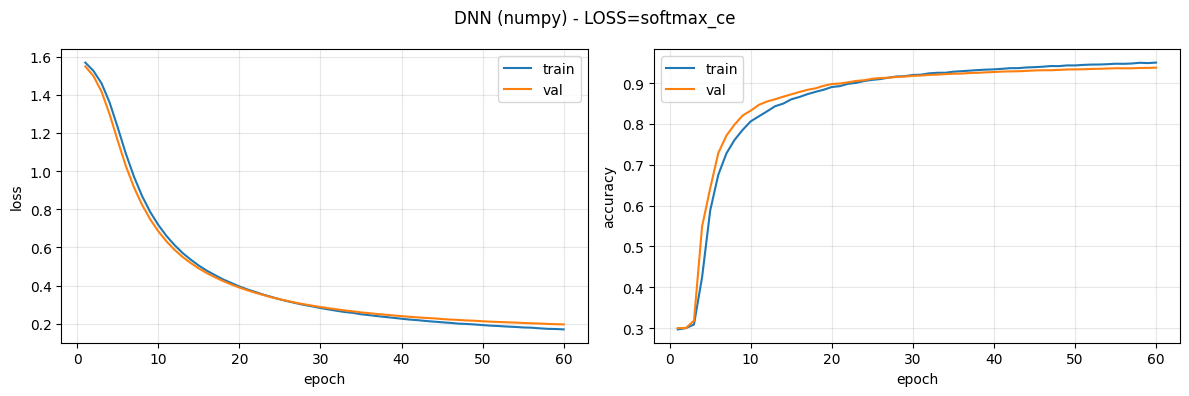

In [51]:
# Plots: loss + accuracy curves (baseline and/or DNN)
import matplotlib.pyplot as plt

def _history_to_series(history: dict):
    """Convert history dict {epoch: {...}} into sorted lists."""
    if not history:
        return [], {}, {}
    epochs = sorted(history.keys())
    keys = set()
    for ep in epochs:
        keys.update(history[ep].keys())
    series = {k: [] for k in keys}
    for ep in epochs:
        row = history[ep]
        for k in keys:
            series[k].append(row.get(k))
    return epochs, series, keys

def plot_training_curves(history: dict, title: str):
    epochs, series, keys = _history_to_series(history)
    if not epochs:
        print(f"{title}: no history to plot")
        return

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(title)

    # Loss
    ax = axes[0]
    if 'loss' in series:
        ax.plot(epochs, series['loss'], label='train')
    if 'val_loss' in series and any(v is not None for v in series['val_loss']):
        ax.plot(epochs, series['val_loss'], label='val')
    ax.set_xlabel('epoch')
    ax.set_ylabel('loss')
    ax.grid(True, alpha=0.3)
    ax.legend()

    # Accuracy / metric
    ax = axes[1]
    if 'metric' in series:
        ax.plot(epochs, series['metric'], label='train')
    if 'val_metric' in series and any(v is not None for v in series['val_metric']):
        ax.plot(epochs, series['val_metric'], label='val')
    ax.set_xlabel('epoch')
    ax.set_ylabel('accuracy')
    ax.grid(True, alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.show()

# Baseline curves (if executed)
if 'base' in globals() and hasattr(base, 'history'):
    plot_training_curves(base.history, 'Baseline: Softmax Regression')
else:
    print('Baseline: not executed (no plots)')

# DNN curves (if executed)
if 'net' in globals() and hasattr(net, 'history'):
    plot_training_curves(net.history, f"DNN (numpy) - LOSS={LOSS}")
else:
    print('DNN: not executed (no plots)')